In [50]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.cluster import KMeans
import numpy as np
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from scipy.spatial.distance import cdist
import matplotlib.pyplot as plt


In [51]:
caminho_parquet = r"C:\Users\Pichau\INMET\TODAS_ESTACOES\df_intermediario.parquet"

df_intermediario = pd.read_parquet(caminho_parquet)

In [52]:
#'VARIACAO PRIMEIRA HORA ANTERIOR TEMPERATURA ORVALHO',
#'VARIACAO SEGUNDA HORA ANTERIOR TEMPERATURA ORVALHO',
#'VARIACAO TERCEIRA HORA ANTERIOR TEMPERATURA ORVALHO',

In [53]:
print(df_intermediario[['VARIACAO PRIMEIRA HORA ANTERIOR TEMPERATURA ORVALHO']].isnull().sum())
print(df_intermediario[['VARIACAO SEGUNDA HORA ANTERIOR TEMPERATURA ORVALHO']].isnull().sum())
print(df_intermediario[['VARIACAO TERCEIRA HORA ANTERIOR TEMPERATURA ORVALHO']].isnull().sum())

# aproximadamente 4%  de dados faltantes, vao ser removidos. 

VARIACAO PRIMEIRA HORA ANTERIOR TEMPERATURA ORVALHO    22
dtype: int64
VARIACAO SEGUNDA HORA ANTERIOR TEMPERATURA ORVALHO    10
dtype: int64
VARIACAO TERCEIRA HORA ANTERIOR TEMPERATURA ORVALHO    18
dtype: int64


In [54]:
df_intermediario = df_intermediario.dropna(subset=['VARIACAO PRIMEIRA HORA ANTERIOR TEMPERATURA ORVALHO'])
df_intermediario = df_intermediario.dropna(subset=['VARIACAO SEGUNDA HORA ANTERIOR TEMPERATURA ORVALHO'])
df_intermediario = df_intermediario.dropna(subset=['VARIACAO TERCEIRA HORA ANTERIOR TEMPERATURA ORVALHO'])

# Pto_Orv

In [56]:


# Coeficientes de Magnus
a = 17.625
b = 243.04

# Calculando α(T, RH)
alpha = np.log(df_intermediario["Umidade"] / 100) + (a * df_intermediario["Temp_Amb"]) / (b + df_intermediario["Temp_Amb"])

# Calculando o ponto de orvalho Ts
df_intermediario["Ponto_de_Orvalho_CRIADO"] = round((b * alpha) / (a - alpha),2)


colunas_selecionadas = ['hora',"Temp_Amb", "Umidade", "Pto_Orv", "Ponto_de_Orvalho_CRIADO"]

df_intermediario[colunas_selecionadas]

# Regra Temperatura no ponto de orvalho = https://www.omnicalculator.com/pt/fisica/ponto-de-orvalho




C:\Users\Pichau\anaconda3\Lib\site-packages\pandas\core\arraylike.py:399: RuntimeWarning: invalid value encountered in log
  result = getattr(ufunc, method)(*inputs, **kwargs)


,hora,Temp_Amb,Umidade,Pto_Orv,Ponto_de_Orvalho_CRIADO
0,18,23.5,86.0,21.1,21.02
1,19,23.2,87.0,21.0,20.92
2,11,23.6,77.0,19.3,19.33
3,12,23.9,82.0,20.6,20.64
4,13,25.0,71.0,19.3,19.38
...,...,...,...,...,...
508297,19,28.1,74.0,23.0,23.03
508298,20,26.9,75.0,22.1,22.09
508299,21,26.0,76.0,21.5,21.44
508300,22,26.0,77.0,21.7,21.65


In [57]:
# Filtrando para verificar onde a diferença do ponto de orvalho com o ponto de orvalho criado for maior que 1 


df_diff =  df_intermediario[abs(df_intermediario["Pto_Orv"] - df_intermediario["Ponto_de_Orvalho_CRIADO"]) > 1]

colunas_selecionadas = ['hora',"Temp_Amb", "Umidade", "Pto_Orv", "Ponto_de_Orvalho_CRIADO"]

df_diff[colunas_selecionadas]

,hora,Temp_Amb,Umidade,Pto_Orv,Ponto_de_Orvalho_CRIADO
27092,2,19.6,11.0,-9999.0,-11.71
70887,13,-9999.0,69.0,-9999.0,-63228.10
209971,21,23.3,73.0,12.7,18.19
209982,8,18.4,69.0,7.1,12.61
209986,12,20.2,63.0,11.7,12.93
...,...,...,...,...,...
363549,5,-9999.0,93.0,-9999.0,-11930.77
363550,6,-9999.0,90.0,-9999.0,-13079.17
363551,7,-9999.0,95.0,-9999.0,-11289.46
363552,8,-9999.0,95.0,-9999.0,-11289.46


In [58]:
# Removendo casos onde Temp_Amb = - 9999.0

df_intermediario = df_intermediario[df_intermediario["Temp_Amb"] != -9999.0]
df_intermediario = df_intermediario[df_intermediario["Pto_Orv"] != -9999.0]



In [59]:
df_diff =  df_intermediario[abs(df_intermediario["Pto_Orv"] - df_intermediario["Ponto_de_Orvalho_CRIADO"]) > 1]

colunas_selecionadas = ['hora',"Temp_Amb", "Umidade", "Pto_Orv", "Ponto_de_Orvalho_CRIADO"]

df_diff[colunas_selecionadas]

# 

,hora,Temp_Amb,Umidade,Pto_Orv,Ponto_de_Orvalho_CRIADO
209971,21,23.3,73.0,12.7,18.19
209982,8,18.4,69.0,7.1,12.61
209986,12,20.2,63.0,11.7,12.93
213520,11,20.5,43.0,17.5,7.49
213521,12,21.6,39.0,17.6,7.05
213547,17,23.1,39.0,20.5,8.39


# VARIACAO PRIMEIRA HORA ANTERIOR TEMPERATURA ORVALHO - Kmeans

In [61]:
df_intermediario['VARIACAO PRIMEIRA HORA ANTERIOR TEMPERATURA ORVALHO'].describe()

count    490466.000000
mean          2.470132
std         119.501717
min           0.000000
25%           0.500000
50%           0.800000
75%           1.400000
max       10023.900000
Name: VARIACAO PRIMEIRA HORA ANTERIOR TEMPERATURA ORVALHO, dtype: float64

In [62]:
# São oriundos do Pt orvalho que removi , os valores de >1000

df_intermediario = df_intermediario[df_intermediario['VARIACAO PRIMEIRA HORA ANTERIOR TEMPERATURA ORVALHO'] < 500]
df_intermediario = df_intermediario[df_intermediario['VARIACAO SEGUNDA HORA ANTERIOR TEMPERATURA ORVALHO'] < 500]
df_intermediario = df_intermediario[df_intermediario['VARIACAO TERCEIRA HORA ANTERIOR TEMPERATURA ORVALHO'] < 500]




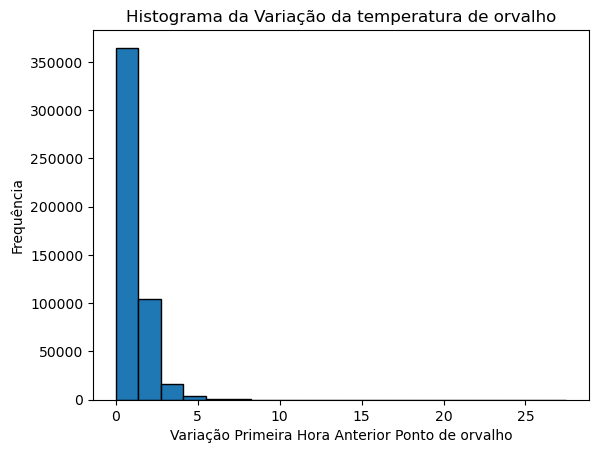

In [63]:

coluna = "VARIACAO PRIMEIRA HORA ANTERIOR TEMPERATURA ORVALHO"

plt.hist(df_intermediario[coluna], bins= 20, edgecolor="black")
plt.xlabel("Variação Primeira Hora Anterior Ponto de orvalho")
plt.ylabel("Frequência")
plt.title("Histograma da Variação da temperatura de orvalho")
plt.show()


In [64]:

'''
X = df_intermediario[['VARIACAO PRIMEIRA HORA ANTERIOR TEMPERATURA ORVALHO']]

silhouette_scores = []
K_range = range(2, 11)  

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=10)
    labels = kmeans.fit_predict(X)
    sil_score = silhouette_score(X, labels)
    silhouette_scores.append(sil_score)

plt.plot(K_range, silhouette_scores, marker='o')
plt.xlabel('Número de Clusters')
plt.ylabel('Índice de Silhueta')
plt.title('Índice de Silhueta para diferentes K')
plt.show()
'''

"\nX = df_intermediario[['VARIACAO PRIMEIRA HORA ANTERIOR TEMPERATURA ORVALHO']]\n\nsilhouette_scores = []\nK_range = range(2, 11)  \n\nfor k in K_range:\n    kmeans = KMeans(n_clusters=k, random_state=10)\n    labels = kmeans.fit_predict(X)\n    sil_score = silhouette_score(X, labels)\n    silhouette_scores.append(sil_score)\n\nplt.plot(K_range, silhouette_scores, marker='o')\nplt.xlabel('Número de Clusters')\nplt.ylabel('Índice de Silhueta')\nplt.title('Índice de Silhueta para diferentes K')\nplt.show()\n"

In [65]:
#########################################################################################################

In [66]:
#########################################################################################################

In [67]:
#########################################################################################################

In [68]:
X = df_intermediario[['VARIACAO PRIMEIRA HORA ANTERIOR TEMPERATURA ORVALHO']]

n_clusters = 3  

kmeans = KMeans(n_clusters = 3, random_state= 10)

df_intermediario['VARIACAO PRIMEIRA HORA ANTERIOR TEMPERATURA ORVALHO CLUSTER K MEANS'] = kmeans.fit_predict(X)

# Obter os centróides dos clusters 
centroids = kmeans.cluster_centers_

print("Centróides de 'VARIACAO PRIMEIRA HORA ANTERIOR TEMPERATURA ORVALHO CLUSTER K MEANS': ", centroids)

df_intermediario['VARIACAO PRIMEIRA HORA ANTERIOR TEMPERATURA ORVALHO CLUSTER K MEANS - ROTULOS'] = df_intermediario['VARIACAO PRIMEIRA HORA ANTERIOR TEMPERATURA ORVALHO CLUSTER K MEANS'].map({
    0: 'medio',      # Cluster com centróide 1.45779806
    1: 'alto',     # Cluster com 3.28853746
    2: 'baixo' ,     # Cluster com centróide 0.51386441   
})


Centróides de 'VARIACAO PRIMEIRA HORA ANTERIOR TEMPERATURA ORVALHO CLUSTER K MEANS':  [[1.45779806]
 [3.28853746]
 [0.51386441]]


In [69]:
centroids_manual = np.array([
    [1.45779806],
    [3.28853746],
    [0.51386441]
])

In [70]:
X_novo = df_intermediario[['VARIACAO SEGUNDA HORA ANTERIOR TEMPERATURA ORVALHO']]

# Calcular a distância de cada ponto aos centróides e encontrar o cluster mais próximo
df_intermediario['VARIACAO SEGUNDA HORA ANTERIOR TEMPERATURA ORVALHO CLUSTER K MEANS'] = np.argmin(
    cdist(X_novo, centroids_manual), axis=1
)

# Manter os mesmos rótulos de cluster
df_intermediario['VARIACAO SEGUNDA HORA ANTERIOR TEMPERATURA ORVALHO CLUSTER K MEANS - ROTULOS'] = df_intermediario[
    'VARIACAO SEGUNDA HORA ANTERIOR TEMPERATURA ORVALHO CLUSTER K MEANS'
].map({
    0: 'medio',      # Cluster com centróide 2.41693442
    1: 'alto',     # Cluster com 8.30201311
    2: 'baixo'      # Cluster com centróide 19.1638187
})

df_intermediario[['VARIACAO SEGUNDA HORA ANTERIOR TEMPERATURA ORVALHO', 
                        'VARIACAO SEGUNDA HORA ANTERIOR TEMPERATURA ORVALHO CLUSTER K MEANS', 
                        'VARIACAO SEGUNDA HORA ANTERIOR TEMPERATURA ORVALHO CLUSTER K MEANS - ROTULOS']]

,VARIACAO SEGUNDA HORA ANTERIOR TEMPERATURA ORVALHO,VARIACAO SEGUNDA HORA ANTERIOR TEMPERATURA ORVALHO CLUSTER K MEANS,VARIACAO SEGUNDA HORA ANTERIOR TEMPERATURA ORVALHO CLUSTER K MEANS - ROTULOS
0,0.0,2,baixo
1,0.1,2,baixo
2,0.0,2,baixo
3,1.1,0,medio
4,1.2,0,medio
...,...,...,...
508297,1.5,0,medio
508298,0.8,2,baixo
508299,0.9,2,baixo
508300,0.9,2,baixo


In [71]:
X_novo = df_intermediario[['VARIACAO TERCEIRA HORA ANTERIOR TEMPERATURA ORVALHO']]

# Calcular a distância de cada ponto aos centróides e encontrar o cluster mais próximo
df_intermediario['VARIACAO TERCEIRA HORA ANTERIOR TEMPERATURA ORVALHO CLUSTER K MEANS'] = np.argmin(
    cdist(X_novo, centroids_manual), axis=1
)

# Manter os mesmos rótulos de cluster
df_intermediario['VARIACAO TERCEIRA HORA ANTERIOR TEMPERATURA ORVALHO CLUSTER K MEANS - ROTULOS'] = df_intermediario[
    'VARIACAO TERCEIRA HORA ANTERIOR TEMPERATURA ORVALHO CLUSTER K MEANS'
].map({
    0: 'medio',      # Cluster com centróide 1.45779806
    1: 'alto',     # Cluster com 3.28853746
    2: 'baixo'      # Cluster com centróide 0.51386441
})

df_intermediario[['VARIACAO TERCEIRA HORA ANTERIOR TEMPERATURA ORVALHO', 
                        'VARIACAO TERCEIRA HORA ANTERIOR TEMPERATURA ORVALHO CLUSTER K MEANS', 
                        'VARIACAO TERCEIRA HORA ANTERIOR TEMPERATURA ORVALHO CLUSTER K MEANS - ROTULOS']]

,VARIACAO TERCEIRA HORA ANTERIOR TEMPERATURA ORVALHO,VARIACAO TERCEIRA HORA ANTERIOR TEMPERATURA ORVALHO CLUSTER K MEANS,VARIACAO TERCEIRA HORA ANTERIOR TEMPERATURA ORVALHO CLUSTER K MEANS - ROTULOS
0,0.0,2,baixo
1,0.0,2,baixo
2,0.0,2,baixo
3,0.0,2,baixo
4,1.1,0,medio
...,...,...,...
508297,1.3,0,medio
508298,1.5,0,medio
508299,0.8,2,baixo
508300,0.9,2,baixo


In [72]:
caminho_parquet = r"C:\Users\Pichau\INMET\TODAS_ESTACOES\df_intermediario.parquet"

df_intermediario.to_parquet(caminho_parquet, index=False)